# Experimento 6 — Modelo en dos niveles (polaridad por oración + gradient boosting)

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento5.ipynb`. La sección 1 repite de forma resumida la configuración común (misma
semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a ejecutar**: sus métricas se
registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 6 — Modelo en dos niveles

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de los experimentos 2 a 5 tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099, "f1_cv": 0.8908,
     "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 3, "descripcion": "TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9980, "acc_cv": 0.7978, "std_cv": 0.0146, "f1_cv": 0.8064,
     "acc_test": 0.7963, "f1_test": 0.8054, "envio": "submission_03.csv", "kaggle_publico": None},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057,
     "f1_cv": 0.9055, "acc_test": 0.8975, "f1_test": 0.9021, "envio": "submission_04.csv", "kaggle_publico": None},
    {"experimento": 5, "descripcion": "Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9773, "acc_cv": 0.9022, "std_cv": 0.0080,
     "f1_cv": 0.9068, "acc_test": 0.9021, "f1_test": 0.9068, "envio": "submission_05.csv", "kaggle_publico": None},
]:
    resultados.append(fila)

# Accuracy por fold del experimento 5 (mismos folds; experimento5.ipynb, sección 2.2, variante A)
ACC_FOLDS_E5 = np.array([0.9036, 0.9047, 0.9052, 0.9104, 0.8870])

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 2", "escenario": "Original", "accuracy": 0.8992},
    {"modelo": "Exp. 2", "escenario": "Oraciones desordenadas", "accuracy": 0.6858},
    {"modelo": "Exp. 2", "escenario": "Última oración al inicio", "accuracy": 0.5742},
    {"modelo": "Exp. 5", "escenario": "Original", "accuracy": 0.9021},
    {"modelo": "Exp. 5", "escenario": "Oraciones desordenadas", "accuracy": 0.7379},
    {"modelo": "Exp. 5", "escenario": "Última oración al inicio", "accuracy": 0.5954},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
4,5,"Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9773,0.9022,0.0080,0.9068,0.9021,0.9068,submission_05.csv,NaN


## 2. Experimento 6 — Modelo en dos niveles

**Motivación:** el experimento 5 mostró que el modelo ya acierta el 95,7 % fuera de los grupos con etiqueta
aleatoria, y que el techo es ≈ 0,937. Para recuperar parte del margen restante (≈ 3,5 puntos) se intentó que el
modelo aprendiera reglas del tipo *"si la última opinión empieza con un conector secundario, pesa menos"*. Con un
modelo lineal sobre TF-IDF esa **interacción** solo se puede expresar repartiendo las oraciones en muchas columnas
dispersas, y empeoró (cada columna quedaba con pocos datos).

**Idea:** separar el problema en dos niveles.
1. **Nivel 1 — modelos de texto:** resumir cada reseña en unos pocos números: los puntajes del modelo del
   experimento 5 y la **polaridad estimada de cada una de las últimas oraciones con opinión**.
2. **Nivel 2 — combinador:** un clasificador sobre esas pocas **features densas** (puntajes, polaridades, tipo de
   conector de cada oración, si termina en evasiva...). Con pocas features y muchos datos por feature, un modelo de
   árboles como **HistGradientBoosting** puede aprender interacciones ("tipo de conector × polaridad") sin el problema
   de dispersión.

Esta técnica se conoce como **stacking** (apilamiento de modelos).

**Nota sobre los árboles:** en la Parte 1 se descartó Random Forest **sobre el TF-IDF** (decenas de miles de
features dispersas, sección de descartes del README). Aquí el modelo de árboles trabaja sobre **17 features densas**
ya resumidas por modelos lineales, que es justamente el escenario donde los árboles funcionan bien.

**Proceso:**
1. Definir los modelos de nivel 1 y las features de nivel 2.
2. Entrenar con **cross-fitting** para evitar leakage (ver 2.2).
3. Comparar dos combinadores de nivel 2 (regresión logística y HistGradientBoosting) con CV, fold por fold contra el
   experimento 5.
4. Evaluar en test (incluida la prueba de robustez) y generar el envío.

### 2.1 Definiciones del experimento 5

Las mismas funciones y el mismo transformador `PartesE5` de `experimento5.ipynb` (sección 2.1).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Arquitectura y cross-fitting

**Nivel 1** (se entrena con las reseñas de entrenamiento):
- **Modelo base:** el pipeline del experimento 5 (`PartesE5(quitar=True)` + TF-IDF por partes + LinearSVC `C = 0,2`).
  Aporta un puntaje por clase (`decision_function`).
- **Modelo de polaridad de oraciones:** TF-IDF + regresión logística entrenado con la **última oración con opinión**
  de las reseñas `negativo`/`positivo` (sin su conector inicial), etiquetada con la clase de la reseña. Da un puntaje
  de polaridad para cualquier oración.

**Features de nivel 2** (17 por reseña):

| Feature | Cantidad |
|---|---|
| Puntajes del modelo base (`negativo`, `neutral`, `positivo`) | 3 |
| Polaridad de la antepenúltima, penúltima y última oración con opinión | 3 |
| Número de oraciones con opinión · termina en evasiva · última y penúltima opinión de signo contrario | 3 |
| Grupo del conector de la última opinión (conclusivo / secundario / "eso sí, la verdad" / ninguno) | 4 |
| Grupo del conector de la penúltima opinión | 4 |

**Cross-fitting (para evitar leakage):** si el nivel 2 se entrenara con features calculadas por modelos de nivel 1
que **ya vieron** esas mismas reseñas, las features serían demasiado optimistas (el modelo base acierta casi el 98 %
en train) y el nivel 2 aprendería a confiar de más en ellas. Por eso, dentro de `fit`:
1. Las reseñas de entrenamiento se dividen en 5 partes internas. Para cada parte, los modelos de nivel 1 se entrenan
   con las otras 4 y calculan las features de esa parte. Así **cada reseña tiene features calculadas por modelos que
   no la vieron**, igual que ocurrirá con reseñas nuevas.
2. El nivel 2 se entrena con esas features.
3. Los modelos de nivel 1 se vuelven a entrenar con todas las reseñas de entrenamiento, para usarlos al predecir.

Todo ocurre dentro de `fit`, así que en la CV externa cada fold de validación sigue sin participar en nada.

In [7]:
from sklearn.base import ClassifierMixin
from sklearn.ensemble import HistGradientBoostingClassifier

NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
NOMBRES_FEATURES = (["base_negativo", "base_neutral", "base_positivo",
                     "pol_antepenultima", "pol_penultima", "pol_ultima",
                     "n_opiniones", "termina_evasiva", "ultimas_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


class DosNiveles(BaseEstimator, ClassifierMixin):
    """Stacking: nivel 1 = modelo del exp. 5 + polaridad por oración; nivel 2 = combinador sobre 17 features densas."""

    def __init__(self, nivel2="hgb", k_interno=5):
        self.nivel2 = nivel2
        self.k_interno = k_interno

    def _fit_nivel1(self, X, y):
        base = pipeline_e5(quitar=True).fit(X, y)
        partes = base.named_steps["partes"]
        es_np = np.asarray(y) != "neutral"
        ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, m in zip(X, es_np) if m]
        polaridad = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
        ]).fit(ultimas, np.asarray(y)[es_np])
        return base, polaridad

    @staticmethod
    def _features(X, base, polaridad):
        puntajes = base.decision_function(X)
        partes = base.named_steps["partes"]
        filas = []
        for texto, p in zip(X, puntajes):
            ops = partes.opiniones(texto)
            pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
            pols = [0.0] * (3 - len(pols)) + pols
            g_ult = grupo_conector(ops[-1])
            g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
            fila = list(p) + pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])),
                                     float(pols[-1] * pols[-2] < 0)]
            fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
            filas.append(fila)
        return np.array(filas)

    def _nuevo_nivel2(self):
        if self.nivel2 == "hgb":
            return HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
                                                  l2_regularization=1.0, random_state=SEED)
        return LogisticRegression(C=1, max_iter=3000, random_state=SEED)

    def fit(self, X, y):
        X = pd.Series(list(X))
        y = np.asarray(y)
        F = np.zeros((len(X), len(NOMBRES_FEATURES)))
        interno = StratifiedKFold(self.k_interno, shuffle=True, random_state=SEED)
        for idx_tr, idx_va in interno.split(X, y):          # cross-fitting
            base, polaridad = self._fit_nivel1(X.iloc[idx_tr], y[idx_tr])
            F[idx_va] = self._features(X.iloc[idx_va], base, polaridad)
        self.base_, self.polaridad_ = self._fit_nivel1(X, y)
        self.nivel2_ = self._nuevo_nivel2().fit(F, y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        X = pd.Series(list(X))
        return self.nivel2_.predict(self._features(X, self.base_, self.polaridad_))

### 2.3 Comparación de combinadores de nivel 2

`GridSearchCV` compara los dos combinadores (regresión logística y HistGradientBoosting) con los mismos 5 folds. Cada
evaluación entrena el nivel 1 seis veces (5 internas + 1 final), por lo que esta celda tarda ≈ 30 minutos.

In [8]:
busqueda_e6 = GridSearchCV(
    DosNiveles(), {"nivel2": ["lr", "hgb"]}, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e6.fit(X_train, y_train)

print("Mejor combinador:", busqueda_e6.best_params_["nivel2"])
print(f"Accuracy CV: {busqueda_e6.best_score_:.4f}")
tabla_e6 = tabla_cv(busqueda_e6)
tabla_e6.insert(0, "nivel 2", tabla_e6.pop("params").map(lambda p: p["nivel2"]))
tabla_e6

Mejor combinador: hgb
Accuracy CV: 0.9039


,nivel 2,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
1,hgb,0.9392,0.9039,0.0102,0.9085,112.4846
0,lr,0.9660,0.9018,0.0050,0.9065,111.0934


In [9]:
cv = busqueda_e6.cv_results_
por_fold = {"[ref. exp. 5]": ACC_FOLDS_E5}
for i, p in enumerate(cv["params"]):
    por_fold[f"dos niveles ({p['nivel2']})"] = np.array([cv[f"split{k}_test_accuracy"][i] for k in range(5)])

comparacion = pd.DataFrame(por_fold, index=[f"fold {k}" for k in range(1, 6)]).T
comparacion["media"] = comparacion.mean(axis=1)
comparacion["folds que gana al exp. 5"] = [int((v > ACC_FOLDS_E5).sum()) for v in por_fold.values()]
comparacion.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5,media,folds que gana al exp. 5
[ref. exp. 5],0.9036,0.9047,0.9052,0.9104,0.8870,0.9022,0
dos niveles (lr),0.9021,0.9005,0.9083,0.9047,0.8932,0.9018,2
dos niveles (hgb),0.9083,0.8969,0.9120,0.9146,0.8875,0.9039,4


**Lectura**

- **HistGradientBoosting es el mejor combinador:** 0,9039 ± 0,0102 de accuracy en CV, frente a 0,9022 del
  experimento 5 (+0,17 puntos), y gana en **4 de 5 folds**. La mejora media está dentro de la desviación entre folds,
  así que en CV es un resultado positivo pero no concluyente.
- **La regresión logística como combinador no mejora** (0,9018): una combinación lineal de las mismas features no
  aporta nada sobre el modelo base. La ganancia del gradient boosting viene de las **interacciones** entre features
  (por ejemplo, polaridad de la última opinión × grupo de su conector), que es justamente lo que se buscaba.
- **El nivel 2 sobreajusta mucho menos:** accuracy de entrenamiento 0,939, frente a ≈ 0,977 del experimento 5. Al
  trabajar sobre 17 features resumidas (y calculadas con cross-fitting) en lugar de decenas de miles de n-gramas, el
  combinador no puede memorizar reseñas concretas.

### 2.4 Evaluación en test y prueba de robustez

Test -> accuracy: 0.9150 | F1 macro: 0.9191

              precision    recall  f1-score   support

    negativo      0.888     0.873     0.880       843
     neutral      0.996     0.997     0.997       715
    positivo      0.874     0.887     0.880       842

    accuracy                          0.915      2400
   macro avg      0.919     0.919     0.919      2400
weighted avg      0.915     0.915     0.915      2400



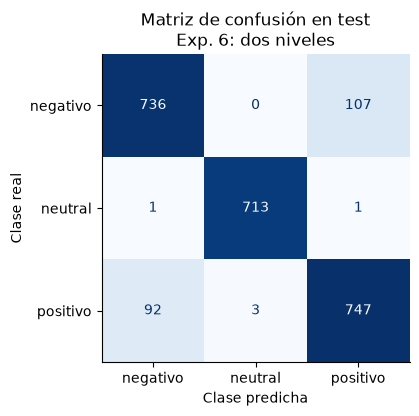

Negativo vs positivo en test: 0.880 (exp. 5: 0,861)


In [10]:
metricas_e6 = evaluar_en_test(busqueda_e6.best_estimator_, "Exp. 6: dos niveles")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e6['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f} (exp. 5: 0,861)")

In [11]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 6", "escenario": e, "accuracy": accuracy_score(y_test, busqueda_e6.best_estimator_.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 2,Exp. 5,Exp. 6
escenario,,,
Original,0.8992,0.9021,0.9150
Oraciones desordenadas,0.6858,0.7379,0.7354
Última oración al inicio,0.5742,0.5954,0.5921


### 2.5 Registro y envío

In [12]:
registrar_resultado(
    experimento=6,
    descripcion="Dos niveles: modelo del exp. 5 + polaridad por oración (cross-fitting) -> combinador "
                + busqueda_e6.best_params_["nivel2"],
    busqueda=busqueda_e6,
    metricas_test=metricas_e6,
    envio="submission_06.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
4,5,"Como el exp. 4, con el detector de opinión aplicado a la oración sin su conector inicial","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9773,0.9022,0.0080,0.9068,0.9021,0.9068,submission_05.csv,NaN
5,6,Dos niveles: modelo del exp. 5 + polaridad por oración (cross-fitting) -> combinador hgb,{'nivel2': 'hgb'},0.9392,0.9039,0.0102,0.9085,0.9150,0.9191,submission_06.csv,NaN


In [13]:
envio_e6 = generar_envio(busqueda_e6, numero=6)

Envío guardado en envios/submission_06.csv y modelo en modelos/modelo_06.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.2
neutral     27.7
positivo    37.1


### 2.6 Análisis del experimento 6

**Resultados:** accuracy de CV = **0,9039 ± 0,0102** (combinador HistGradientBoosting) y accuracy en test =
**0,9150** (F1 macro 0,919).

| | Exp. 2 | Exp. 5 | Exp. 6 |
|---|---|---|---|
| Accuracy CV | 0,8865 | 0,9022 | **0,9039** |
| Accuracy de entrenamiento | 0,9999 | 0,9773 | **0,9392** |
| Accuracy test | 0,8992 | 0,9021 | **0,9150** |
| Negativo vs positivo (test) | 0,859 | 0,861 | **0,880** |
| Test, oraciones desordenadas | 0,686 | 0,738 | 0,735 |
| Test, última oración al inicio | 0,574 | 0,595 | 0,592 |

1. **Es el mejor resultado en CV y en test.** En CV la mejora sobre el experimento 5 es pequeña (+0,17 puntos, gana
   en 4 de 5 folds); en el test es mayor (+1,3 puntos, ≈ 30 reseñas de 2.400), alrededor de dos errores estándar
   (≈ 0,006). Las dos señales apuntan en la misma dirección, aunque con distinta magnitud. Una explicación plausible
   para la diferencia: en la CV cada modelo se entrena con 7.680 reseñas y el nivel 2 recibe features de modelos
   entrenados con ≈ 6.100; el modelo evaluado en test se entrena con las 9.600, y el stacking se beneficia más que un
   modelo lineal de tener más datos (sus dos niveles mejoran a la vez). Aun así, como el test es una sola partición,
   la estimación más prudente de la mejora es la de la CV.
2. **La mejora está donde se esperaba:** entre `negativo` y `positivo` el test pasa de 0,861 a 0,880; `neutral` sigue
   prácticamente perfecta (F1 0,997).
3. **Menos sobreajuste:** el combinador trabaja con 17 features densas calculadas con cross-fitting, y la brecha
   entre entrenamiento y validación baja de ≈ 7,5 a ≈ 3,5 puntos.
4. **Sigue dependiendo de la posición:** la robustez es la misma que la de los experimentos 4 y 5; el nivel 1 se basa
   en la última oración con opinión.
5. **Costo:** el modelo es bastante más complejo (dos niveles, cross-fitting, una clase propia) y tarda unas 6 veces
   más en entrenar. Para la entrega, el `.joblib` necesita que estén definidas las clases `PartesE5` y `DosNiveles`.

**Decisión:** el experimento 6 es el **mejor modelo hasta ahora** según la CV y el test, y se envía como
`submission_06.csv`. Es el candidato principal para la entrega si el score público lo confirma.

**Relación con el techo:** con ≈ 0,937 de techo estimado (experimento 5), el experimento 6 recupera una parte del
margen corregible. Lo que queda son sobre todo errores al leer la polaridad de oraciones concretas.